<a href="https://colab.research.google.com/github/shanmukh-29/my-first-repo/blob/main/MiniProject_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
df=pd.read_csv('/content/ai_learning_lab.csv')
df=df.drop_duplicates()
df.student_name=df.student_name.str.strip()
df.topic=df.topic.str.strip()
df.tool_used=df.tool_used.str.strip()
df.attendance = df.attendance.str.title()
df.lab_completed = df.lab_completed.str.title()
df.api_used = df.api_used.str.title()
df.loc[(df['assignment_score'] < 0) | (df['assignment_score'] > 100), 'assignment_score'] = pd.NA
df.loc[(df['quiz_score']<0) | (df['quiz_score']>100),'quiz_score']=pd.NA
df.loc[df['study_hours']<0,'study_hours']=pd.NA
df.loc[(df['feedback_rating']<0) | (df['feedback_rating']>5),'feedback_rating']=pd.NA
df.assignment_score=df.assignment_score.fillna(df.assignment_score.mean())
df.quiz_score=df.quiz_score.fillna(df.quiz_score.mean())
df.study_hours=df.study_hours.fillna(df.study_hours.median())
df.feedback_rating=df.feedback_rating.fillna(df.feedback_rating.median())
print(df.shape)
print(df.isna().sum())
df.to_csv('cleaned_ai_learning_lab.csv', index=False)
display(df.head())

(105, 12)
student_id          0
student_name        0
batch               0
topic               0
attendance          0
assignment_score    0
quiz_score          0
lab_completed       0
study_hours         0
feedback_rating     0
tool_used           0
api_used            0
dtype: int64


,student_id,student_name,batch,topic,attendance,assignment_score,quiz_score,lab_completed,study_hours,feedback_rating,tool_used,api_used
0,ST001,Rakesh P,AIML-2603,JSON,Present,66.855556,63.208791,Yes,8.60,3.0,VS Code,No
1,ST002,Aarav Sharma,AIML-2602,SQL Basics,Absent,68.000000,65.000000,No,9.80,4.0,colab,Yes
2,ST003,Harsha Vardhan,AIML-2605,EDA,Present,35.000000,68.000000,No,4.70,3.0,colab,Yes
3,ST004,Sirisha P,AIML-2605,eda,Present,96.000000,27.000000,Yes,6.05,3.0,jupyter,Yes
4,ST005,Yashwanth K,AIML-2603,NumPy Basics,Absent,56.000000,94.000000,Yes,4.70,4.0,Jupyter,No


In [4]:
df=pd.read_csv('cleaned_ai_learning_lab.csv')
df['total_score']=df['assignment_score']+df['quiz_score']

def get_performance_level(score):
    if score >= 160:
        return 'Excellent'
    elif 120 <= score <= 159:
        return 'Good'
    elif 80 <= score <= 119:
        return 'Average'
    else:
        return 'Needs Support'

df['performance_level'] = df['total_score'].apply(get_performance_level)
print(df.assignment_score.mean())
print(df.quiz_score.mean())
print(df.study_hours.median())
print(25*'*')
print(df.groupby('performance_level').size())
print(25*'*')
print(df.groupby('topic').total_score.mean())
print(25*'*')
print(df.groupby('batch').total_score.mean())
print(25*'*')
print(df['student_name'][df['performance_level']=='Needs Support'])

66.85555555555555
63.20879120879121
6.05
*************************
performance_level
Average          33
Excellent        14
Good             54
Needs Support     4
dtype: int64
*************************
topic
AI Landscape        133.641758
APIs and Ethics     127.508043
Data Collections    136.766087
Decision Making     121.552198
EDA                 128.841758
File Handling       115.069597
Functions           108.783980
JSON                112.012869
Loops               141.977546
Matplotlib          162.713889
NumPy Basics        151.927778
Pandas Filtering    122.601256
Pandas Grouping     135.971111
Pandas Loading      121.000000
Python Basics       142.909992
SQL Basics          131.500000
SQL basics          123.463889
eda                 123.534142
pandas loading      122.912088
Name: total_score, dtype: float64
*************************
batch
AIML-2601    135.736013
AIML-2602    127.816874
AIML-2603    127.810295
AIML-2604    138.802391
AIML-2605    117.348230
Name: total_sco

,topic,total_score
0,AI Landscape,133.641758
1,APIs and Ethics,127.508043
2,Data Collections,136.766087
3,Decision Making,121.552198
4,EDA,128.841758
5,File Handling,115.069597
6,Functions,108.783980
7,JSON,112.012869
8,Loops,141.977546
9,Matplotlib,162.713889


The below is sorted order


,topic,total_score
9,Matplotlib,162.713889
10,NumPy Basics,151.927778
14,Python Basics,142.909992
8,Loops,141.977546
2,Data Collections,136.766087
12,Pandas Grouping,135.971111
0,AI Landscape,133.641758
15,SQL Basics,131.500000
4,EDA,128.841758
1,APIs and Ethics,127.508043


/tmp/ipykernel_3145/3451702816.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_score', y='topic', data=average_score_by_topic, palette='viridis')


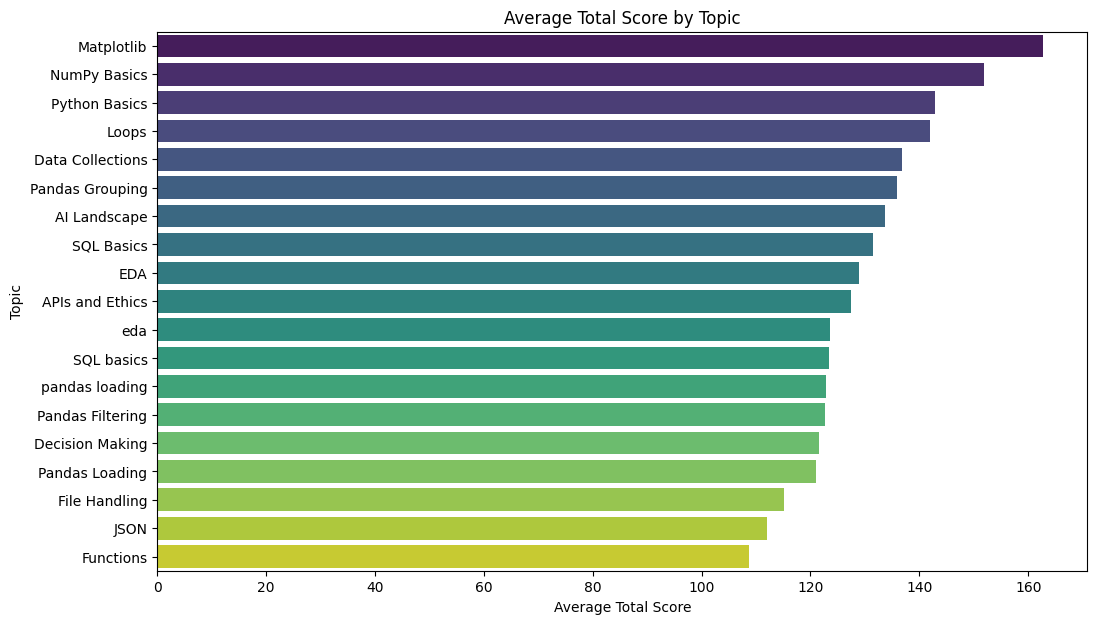

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df['total_score']=df['assignment_score']+df['quiz_score']

average_score_by_topic = df.groupby('topic')['total_score'].mean().reset_index()

display(average_score_by_topic)


average_score_by_topic = average_score_by_topic.sort_values(by='total_score', ascending=False)
print('The below is sorted order')
display(average_score_by_topic)

plt.figure(figsize=(12, 7))
sns.barplot(x='total_score', y='topic', data=average_score_by_topic, palette='viridis')
plt.title('Average Total Score by Topic')
plt.xlabel('Average Total Score')
plt.ylabel('Topic')
plt.savefig('topic_score_chart.png')
plt.show()

,performance_level,student_count
2,Good,54
0,Average,33
1,Excellent,14
3,Needs Support,4


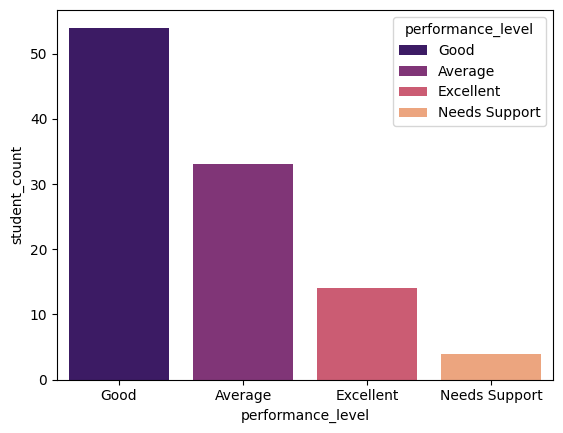

In [21]:
student_count_by_Pl=df.groupby('performance_level').size().reset_index(name='student_count').sort_values(by='student_count',ascending=False)
display(student_count_by_Pl)
sns.barplot(x='performance_level', y='student_count', data=student_count_by_Pl, palette='magma', hue='performance_level', legend=True)
plt.savefig('performance_level_chart.png')
plt.show()

,0
attendance,
Absent,52
Present,53


RangeIndex(start=0, stop=105, step=1)

,count
attendance,
Present,53
Absent,52


Index(['Present', 'Absent'], dtype='object', name='attendance')

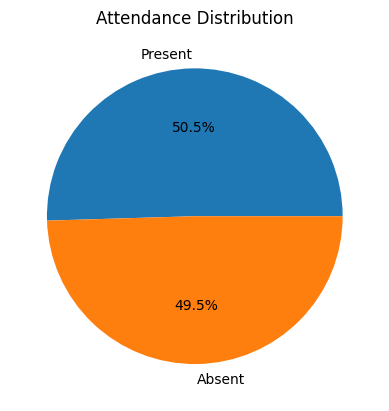

In [22]:
df.attendance=df.attendance.str.strip()
display(df.groupby('attendance').size())
display(df.attendance.index)
display(df.attendance.value_counts())
display(df.attendance.value_counts().index)
plt.pie(df.attendance.value_counts(), labels=df.attendance.value_counts().index, autopct='%1.1f%%')
plt.title('Attendance Distribution')
plt.savefig('attendance_chart.png')
plt.show()

,study_hours
topic,
NumPy Basics,3.050000
Matplotlib,3.525000
Decision Making,3.687500
SQL basics,4.700000
APIs and Ethics,4.950000
Pandas Filtering,4.985714
Functions,5.030000
Pandas Loading,5.500000
File Handling,5.550000


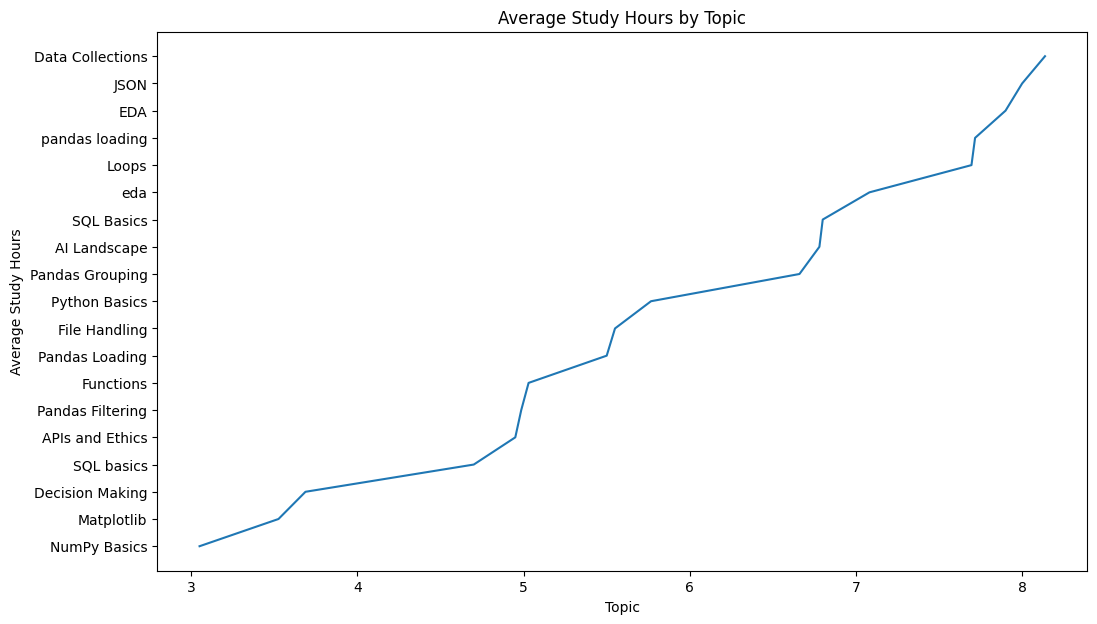

In [23]:
avg_study_topic=df.groupby('topic')['study_hours'].mean().sort_values()
display(avg_study_topic)
plt.figure(figsize=(12, 7))
plt.plot(avg_study_topic.values,avg_study_topic.index)
plt.xlabel('Topic')
plt.ylabel('Average Study Hours')
plt.title('Average Study Hours by Topic')
plt.savefig('study_hours_chart.png')
plt.show()

In [26]:
import json

total_students = len(df['student_id'].unique())
average_assignment_score = df['assignment_score'].mean()
average_quiz_score = df['quiz_score'].mean()
average_study_hours = df['study_hours'].mean()
most_common_topic = df['topic'].mode()[0]

summary_data = {
    'Total number of students': total_students,
    'Average assignment score': average_assignment_score,
    'Average quiz score': average_quiz_score,
    'Average study hours': average_study_hours,
    'Most common topic': most_common_topic
}

with open('learning_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=4)

print("Summary data saved to learning_summary.json")
print(summary_data)

Summary data saved to learning_summary.json
{'Total number of students': 105, 'Average assignment score': np.float64(66.85555555555555), 'Average quiz score': np.float64(63.20879120879121), 'Average study hours': np.float64(6.206190476190476), 'Most common topic': 'Python Basics'}


In [31]:
%%writefile bonus_sql_analysis.py

import sqlite3
import pandas as pd

# Load the cleaned CSV file
df = pd.read_csv('cleaned_ai_learning_lab.csv')

# Calculate total_score, as it was not included in the saved CSV
df['total_score'] = df['assignment_score'] + df['quiz_score']

# Connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect('learning_lab.db')

# Store the DataFrame into a SQLite table named student_learning
df.to_sql('student_learning', conn, if_exists='replace', index=False)

print("Database 'learning_lab.db' created and 'student_learning' table populated.\n")

# Query 1: Average assignment score by topic
print("Query 1: Average assignment score by topic")
query1_result = pd.read_sql_query("SELECT topic, AVG(assignment_score) FROM student_learning GROUP BY topic;", conn)
print(query1_result)
print("\n")

# Query 2: Student count by batch
print("Query 2: Student count by batch")
query2_result = pd.read_sql_query("SELECT batch, COUNT(*) FROM student_learning GROUP BY batch;", conn)
print(query2_result)
print("\n")

# Query 3: Students with total score below 80
print("Query 3: Students with total score below 80")
query3_result = pd.read_sql_query("SELECT student_name, total_score FROM student_learning WHERE total_score < 80;", conn)
print(query3_result)
print("\n")

# Close the database connection
conn.close()
print("Database connection closed.")

Overwriting bonus_sql_analysis.py


In [30]:
!python bonus_sql_analysis.py

Database 'learning_lab.db' created and 'student_learning' table populated.

Query 1: Average assignment score by topic
               topic  AVG(assignment_score)
0       AI Landscape              70.000000
1    APIs and Ethics              65.231944
2   Data Collections              69.463889
3    Decision Making              72.500000
4                EDA              57.800000
5      File Handling              56.666667
6          Functions              61.742222
7               JSON              69.971111
8              Loops              74.056667
9         Matplotlib              80.713889
10      NumPy Basics              61.427778
11  Pandas Filtering              68.142857
12   Pandas Grouping              55.971111
13    Pandas Loading              44.000000
14     Python Basics              74.892593
15        SQL Basics              51.000000
16        SQL basics              59.713889
17               eda              72.106944
18    pandas loading              63.444444

